In [ ]:
# 🚀 To get started, install DeepInverse by creating a new cell and running `%pip install deepinv`

## LOAD DATA

In [105]:
import sirf
from sirf.Utilities import existing_filepath
from sirf.Utilities import error
from sirf.Utilities import show_3D_array
from sirf.Gadgetron import examples_data_path
from sirf.Gadgetron import AcquisitionData, ImageData
from sirf.Gadgetron import AcquisitionModel
from sirf.Gadgetron import AcquisitionDataProcessor
from sirf.Gadgetron import CartesianGRAPPAReconstructor
from sirf.Gadgetron import CoilSensitivityData
from sirf.Gadgetron import preprocess_acquisition_data
from sirf.Gadgetron import FullySampledReconstructor


from cil.optimisation.functions import LeastSquares
from cil.optimisation.functions import ZeroFunction
from cil.optimisation.algorithms import FISTA, CGLS, GD
from cil.plugins.ccpi_regularisation.functions import FGP_TV#, TGV, LLT_ROF, Diff4th
from cil.framework import DataContainer as cilDataContainer
from cil.optimisation.operators import LinearOperator

import numpy
import numpy as np
import time

import matplotlib.pyplot as plt
import os

import deepinv as dinv

In [52]:
import deepinv as dinv
from pathlib import Path
import torch
from torch.utils.data import DataLoader
from deepinv.optim.prior import Prior
from deepinv.optim.data_fidelity import L2
from deepinv.optim import ADMM
from deepinv.training import test
from torchvision import transforms
from deepinv.utils import load_dataset
from torch import nn
device=torch.device('cuda:0')

Available data:

- Conventional reconstruction is non-AI reconstruction. Was acquired with GRAPPA parallel imaging on, acceleration factor 2 (undersampled by 50%). The scanner automatically uses GRAPPA reconstruction.
- The AI recon image has Deep resolve Boost switched on and set to high, Deep Resolve sharp is also switched on (this is a tick-box option on the scanner UI), and GRAPPA acceleration factor is set to 4 (acquire 25% of the fully sampled data).

In [43]:
fname = 'work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5'

In [44]:
acq_data = AcquisitionData(fname)

reading from work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5 using ignore mask 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 

Started reading acquisitions from work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5
0%..10%..20%..30%..40%..50%..60%..70%..80%..90%..100%..
Finished reading acquisitions from work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5


In [45]:
#acq_data.get_header()

In [46]:
acq_data = preprocess_acquisition_data(acq_data)

ignoring acquisition 0
Message received with ID: 5
Input stream has terminated


In [47]:
acq_data.as_array().shape #slices * phase encoding, coils, readout

(2772, 18, 512)

In [48]:
csm = CoilSensitivityData() #Perform self-calibration to compute the coil sensitivity maps
csm.smoothness = 100
csm.calculate(acq_data)

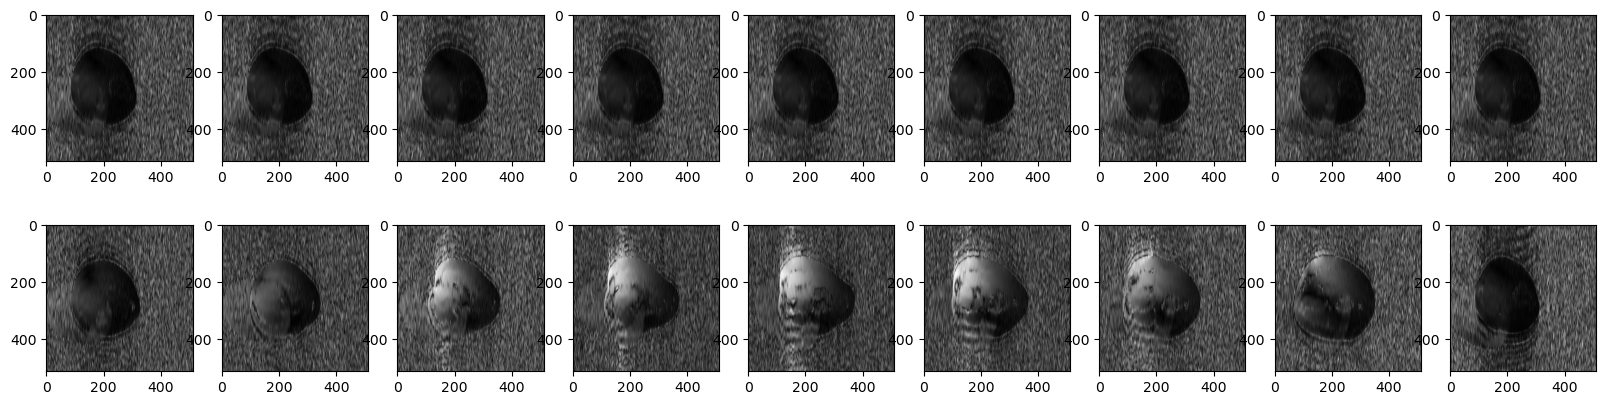

In [49]:
csm.shape
fig,ax=plt.subplots(2,9,figsize=(20,5))
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        csm_slice=abs(np.squeeze(csm.as_array()[9,j*i + i,:,:]))
        ax[i,j].imshow(csm_slice,cmap='gray')

In [50]:
E = AcquisitionModel(acqs=acq_data, imgs=csm) #imgs just determines the grid size, FOV, pixel size etc
E.set_coil_sensitivity_maps(csm)
x_inverse = E.adjoint(acq_data)

In [82]:
acq_data

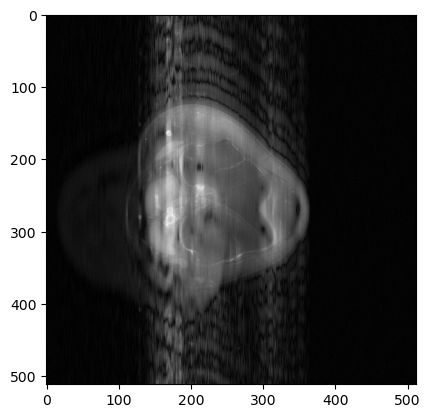

In [51]:
slice_img=np.abs(x_inverse.as_array()[9,:,:])
plt.imshow(slice_img,cmap='gray');plt.show()

## Wrap STIR in pytorch

### Inputs_

In [53]:
#from stir_torch import *


In [74]:
try:
    import torch
except ModuleNotFoundError:
    raise ModuleNotFoundError('Failed to import torch. Please install PyTorch first.')

import sirf.SIRF as sirf


# This module provides a PyTorch interface for SIRF operators and objective functions.
# It wraps SIRF objects to enable their use within PyTorch's autograd system.
# The core idea is to use torch.autograd.Function to define custom forward and backward
# passes that interact with SIRF's C++ backend.  This allows SIRF operations to be
# seamlessly integrated into PyTorch computational graphs.
#
# based on
# https://github.com/educating-dip/pet_deep_image_prior/blob/main/src/deep_image_prior/torch_wrapper.py


def sirf_to_torch(
        sirf_src: sirf.DataContainer | float,
        device: torch.device,
        requires_grad: bool = False
        ) -> torch.Tensor:
    """
    Converts a SIRF object to a PyTorch tensor.

    Args:
        sirf_src: The SIRF object to convert.  This can be a SIRF
          `DataContainer` such as `AcquisitionData`, `ImageData`, or a scalar (float).
        device: The PyTorch device to place the tensor on (e.g., 'cpu' or
          'cuda').
        requires_grad:  Whether the resulting tensor should track gradients.

    Returns:
        A PyTorch tensor representing the SIRF object's data.

    Raises:
        TypeError: If `sirf_src` is not a supported SIRF object or a float.
    """

    if isinstance(sirf_src, float):
        # Handle float separately for efficiency and type consistency.
        return torch.tensor(sirf_src, requires_grad=requires_grad, \
            device=device
            )
    elif hasattr(sirf_src, 'asarray'):
        return torch.as_tensor(sirf_src.asarray(), device=device)
    elif hasattr(sirf_src, 'as_array'):
        # Check for as_array method (ImageData, AcquisitionData, etc.)
        return torch.tensor(sirf_src.as_array(), requires_grad=requires_grad, device=device)
    else:
        raise TypeError(f"Unsupported SIRF object type: {type(sirf_src)}")

def torch_to_sirf_(
        torch_src: torch.Tensor,
        sirf_dest: sirf.DataContainer,
        ) -> sirf.DataContainer:
    """
    Copies data from a PyTorch tensor to a SIRF object in-place.

    This function *modifies* the `sirf_dest` object. It is crucial that
    `sirf_dest` is pre-allocated with the correct shape and data type. This
    function is primarily intended for use within `torch.autograd.Function`
    where in-place operations are more appropriate.

    Args:
        torch_src: The source PyTorch tensor.  It will be detached from the
            computational graph and moved to the CPU before copying.
        sirf_dest: The destination SIRF object. This object will be modified
            in-place.

    Returns:
        The modified `sirf_dest` object.

    Raises:
        TypeError: if `sirf_dest` is not a supported SIRF object
    """

    if hasattr(sirf_dest, 'fill'):
        sirf_dest.fill(torch_src.detach().cpu().numpy())
        return sirf_dest
    else:
        raise TypeError(f"Unsupported SIRF object type for in-place fill: \
            {type(sirf_dest)}"
            )


class _Operator(torch.autograd.Function):
    """
    A PyTorch autograd Function wrapper for SIRF operators.

    This class allows SIRF operators (e.g., projectors, transformations) to be
    used as part of a PyTorch computational graph.  It handles the forward and
    backward passes, converting between SIRF objects and PyTorch tensors.
    """
    @staticmethod
    def forward(ctx,
            torch_src: torch.Tensor,
            sirf_src_template: sirf.DataContainer,
            sirf_operator
            ) -> torch.Tensor:
        """
        Performs the forward pass of the SIRF operator.

        Args:
            ctx: The PyTorch context object for storing information needed for
              the backward pass.
            torch_src: The input PyTorch tensor.
            sirf_src_template: A SIRF object that serves as a template for the
              input to the SIRF operator. It will have its data replaced by the
              content of `torch_src`.
            sirf_operator: The SIRF operator to apply (e.g., a projector).

        Returns:
            A PyTorch tensor representing the result of the SIRF operator
              applied to the input.
        """

        device = torch_src.device
        sirf_src_template = torch_to_sirf_(torch_src, sirf_src_template)
        sirf_dest = sirf_operator.forward(sirf_src_template)
        if torch_src.requires_grad:
            ctx.device = device
            ctx.sirf_dest = sirf_dest
            ctx.sirf_operator = sirf_operator
            return sirf_to_torch(sirf_dest, device, requires_grad=True)
        else:
            return sirf_to_torch(sirf_dest, device)

    @staticmethod
    @torch.autograd.function.once_differentiable
    def backward(ctx,
            grad_output: torch.Tensor
            ) -> tuple[torch.Tensor | None, None, None]:

        sirf_src = ctx.sirf_operator.backward(torch_to_sirf_(grad_output,
                ctx.sirf_dest
                )
            )
        grad = sirf_to_torch(sirf_src, ctx.device, requires_grad=False)
        return grad, None, None

class _ObjectiveFunction(torch.autograd.Function):
    """
    A PyTorch autograd Function wrapper for SIRF objective functions.

    This class enables the use of SIRF objective functions within PyTorch
    optimisation loops. It handles calculating the objective function value and
    its gradient.
    """
    @staticmethod
    def forward(ctx,
            torch_image: torch.Tensor,
            sirf_image_template: sirf.ImageData,
            sirf_obj_func
            ) -> torch.Tensor:
        """
        Calculates the value of the SIRF objective function.

        Args:
            ctx: The PyTorch context object.
            torch_image: The input PyTorch tensor (representing an image).
            sirf_image_template: A SIRF image object that serves as a template.
                Its data will be replaced by `torch_image`.
            sirf_obj_func: The SIRF objective function.

        Returns:
            A PyTorch scalar tensor representing the value of the objective
            function.
        """

        device = torch_image.device
        sirf_image = torch_to_sirf_(torch_image, sirf_image_template)
        if torch_image.requires_grad:
            ctx.device = device
            ctx.sirf_image = sirf_image
            ctx.sirf_obj_func = sirf_obj_func
            # ensure value is a tensor with requires_grad=True
            return sirf_to_torch(sirf_obj_func(sirf_image), device,
                requires_grad=True)
        else:
            return sirf_to_torch(sirf_obj_func(sirf_image), device)

    @staticmethod
    @torch.autograd.function.once_differentiable
    def backward(ctx,
            grad_output: torch.Tensor
            ) -> tuple[torch.Tensor | None, None, None]:
        """
        Calculates the gradient of the SIRF objective function.

        Args:
            ctx: The PyTorch context object.
            grad_output: The gradient of the loss with respect to the output
              of the forward pass (which is the objective function value).
              This will normally be a tensor containing the scalar value 1.

        Returns:
            A tuple containing the gradient of the loss with respect to the
            input image, and None for the other inputs.  The gradient is
            scaled by `grad_output`.
        """

        sirf_obj_func = ctx.sirf_obj_func
        sirf_image = ctx.sirf_image
        device = ctx.device
        sirf_grad = sirf_obj_func.get_gradient(sirf_image)
        grad = sirf_to_torch(sirf_grad, device, requires_grad=False)
        return grad_output*grad, None, None


class _ObjectiveFunctionGradient(torch.autograd.Function):
    """
    A PyTorch autograd Function wrapper for the *gradient* of SIRF objective
    functions. Returns the gradient (not the objective value) in the forward
    pass, and computes the Hessian-vector product in the backward pass.
    """
    @staticmethod
    def forward(ctx,
            torch_image: torch.Tensor,
            sirf_image_template: sirf.ImageData,
            sirf_obj_func
            ) -> torch.Tensor:
        """
        Calculates the *gradient* of the SIRF objective function.

        Args:
            ctx: The PyTorch context object.
            torch_image: The input PyTorch tensor (representing an image).
            sirf_image_template:  A SIRF image object used as a template. Its
              data will be replaced by the content of `torch_image`.
            sirf_obj_func: The SIRF objective function.

        Returns:
            A PyTorch tensor representing the gradient of the objective function.
        """

        device = torch_image.device
        sirf_image = torch_to_sirf_(torch_image, sirf_image_template)
        if torch_image.requires_grad:
            ctx.device = device
            ctx.sirf_image = sirf_image
            ctx.sirf_obj_func = sirf_obj_func
            return sirf_to_torch(sirf_obj_func.get_gradient(sirf_image),
                device, requires_grad=True
                )
        else:
            return sirf_to_torch(sirf_obj_func.get_gradient(sirf_image), device)

    @staticmethod
    @torch.autograd.function.once_differentiable
    def backward(ctx,
            grad_output: torch.Tensor
            ) -> tuple[torch.Tensor | None, None, None]:
        """
        Calculates the Hessian-vector product (HVP) for the SIRF objective
        function.

        Args:
            ctx: The PyTorch context object.
            grad_output: The gradient of the loss with respect to the output of
              the forward pass (which is the *gradient* of the objective
              function).
              Represents the "vector" in the HVP.

        Returns:
            A tuple containing the HVP, and None for the other inputs. The HVP
            represents the gradient of the loss with respect to the input image,
            accounting for the second-order derivatives.
        """

        sirf_obj_func = ctx.sirf_obj_func
        sirf_image = ctx.sirf_image
        device = ctx.device

        sirf_grad = torch_to_sirf_(grad_output, sirf_image.clone())
        # arguments current estimate and input_ (i.e. the vector)
        sirf_HVP = sirf_obj_func.multiply_with_Hessian(sirf_image, sirf_grad)

        torch_HVP = sirf_to_torch(sirf_HVP, device, requires_grad=False)
        return torch_HVP, None, None

def check_shapes(torch_shape, sirf_shape):
    """
    Checks if the PyTorch and SIRF shapes are compatible.

    Args:
        torch_shape: The shape of the PyTorch tensor (excluding batch and
          channel dimensions).
        sirf_shape: The shape of the SIRF object.

    Raises:
        ValueError: If the shapes are not compatible.
    """
    if torch_shape != sirf_shape:
        raise ValueError(f"Invalid shape. Expected sirf shape {sirf_shape} but \
            got torch shape {torch_shape}")


def apply_wrapped_sirf(wrapped_sirf_func, torch_src, sirf_src_shape):
    """
    Applies a wrapped SIRF function to a batched PyTorch tensor.

    This function handles the batch and channel dimensions of the input tensor,
    applying the wrapped SIRF function to each element of the batch and channel.

    Args:
        wrapped_sirf_func:  A function that takes a single PyTorch tensor
          (representing a single SIRF object's data) and applies the wrapped
          SIRF operation (either an Operator or an ObjectiveFunction).
        torch_src: The input PyTorch tensor. Dimensions (batch, channel,
          *sirf_object_shape).  If the channel dimension is not present, it's
          added temporarily.
        sirf_src_shape: The expected shape of the SIRF object.

    Returns:
        A PyTorch tensor representing the result of applying the wrapped SIRF
        function to each element of the batch and channel.

    Raises:
        ValueError: If the input tensor shape is invalid.
    """
    torch_src_shape = torch_src.shape
    if len(torch_src_shape) == len(sirf_src_shape):
        raise ValueError(f"Invalid shape of src. Expected a batch dim. Such \
            that the dims are [batch, {sirf_src_shape}]")
    elif len(torch_src_shape) == len(sirf_src_shape) + 1:
        check_shapes(torch_src_shape[1:], sirf_src_shape)
        if sirf_src_shape == torch_src_shape[1:]:
            torch_src = torch_src.unsqueeze(1) # add channel dimension
            channel = False
    elif len(torch_src_shape) == len(sirf_src_shape) + 2:
        check_shapes(torch_src_shape[2:], sirf_src_shape)
        channel = True
    else:
        raise ValueError(f"Invalid shape of src. Expected batch (+ channel)\
            dim, and {sirf_src_shape}, got {torch_src_shape}")

    n_batch = torch_src.shape[0]
    n_channel = torch_src.shape[1]

    # This looks horrible, but PyTorch will be able to trace.
    batch_values = []
    for batch in range(n_batch):
        channel_values = []
        for channel in range(n_channel):
            channel_values.append(wrapped_sirf_func(torch_src[batch, channel]))
        batch_values.append(torch.stack(channel_values, dim=0))

    # [batch, channel, *value.shape]
    out = torch.stack(batch_values, dim=0)
    if channel:
        # [batch, channel, *value.shape]
        return out
    else:
        # [batch, *value.shape]
        return out.squeeze(1)

class Operator(torch.nn.Module):
    """
    A PyTorch Module that wraps a SIRF operator for use in a neural network.

    This class allows a SIRF operator (like a projector) to be used as a
    layer within a PyTorch `nn.Module`. It handles the conversion between
    PyTorch tensors and SIRF objects and manages batch and channel dimensions.
    """
    def __init__(self,
            operator,
            sirf_src_template: sirf.DataContainer
            ):
        """
        Initializes the Operator.

        Args:
            operator: The SIRF operator to wrap.
            sirf_src_template: A SIRF object (e.g., `sirf.ImageData`) that
              serves as a template for the input to the operator.  Its shape
              will be used to validate input tensors.  The data in this object
              is *not* used during the forward pass, only its geometry.
        """
        super(Operator, self).__init__()
        # get the shape of src
        self.operator=operator
        self.sirf_src_template=sirf_src_template
        self.wrapped_sirf_operator = lambda x: _Operator.apply(x,
            sirf_src_template,
            operator
            )

        self.sirf_src_shape = sirf_src_template.shape

    def forward(self, torch_src: torch.Tensor) -> torch.Tensor:
        """
        Applies the wrapped SIRF operator to the input tensor.

        Args:
            torch_src: The input PyTorch tensor.  Expected dimensions are
              `[batch, channel, *sirf_src_shape]` or `[batch, *sirf_src_shape]`.

        Returns:
            A PyTorch tensor representing the result of the SIRF operator.
            The output dimensions will be `[batch, channel, *sirf_dest_shape]`
            or `[batch, *sirf_dest_shape]`, where `sirf_dest_shape` is the
            natural output shape of the SIRF operator.

        Raises:
            ValueError:  If the input tensor has an invalid shape.  See
                `apply_wrapped_sirf` for details.
        """

        return apply_wrapped_sirf(self.wrapped_sirf_operator, torch_src,
            self.sirf_src_shape
            )
    def A(self,*args,**kwargs):
        return self.forward(*args,**kwargs)

#    def A_adjoint(self, torch_src: torch.Tensor):
#        device = torch_src.device
#        self.sirf_src_template = torch_to_sirf_(torch_src, self.sirf_src_template)
#        sirf_dest = sirf_operator.adjoint(self.sirf_src_template)
#        if torch_src.requires_grad:
#            ctx.device = device
#            ctx.sirf_dest = sirf_dest
#            ctx.sirf_operator = sirf_operator
#            return sirf_to_torch(sirf_dest, device, requires_grad=True)
#        else:
#            return sirf_to_torch(sirf_dest, device)


class ObjectiveFunction(torch.nn.Module):
    """
    A PyTorch Module that wraps a SIRF objective function.

    This class allows a SIRF objective function to be evaluated within a
    PyTorch training loop. It handles the necessary conversions and provides
    the objective function value. The gradient is handled by the autograd
    Function `_ObjectiveFunction`.
    """
    def __init__(self,
            sirf_obj_func,
            sirf_image_template: sirf.ImageData
            ):
        """
        Initializes the ObjectiveFunction.

        Args:
            sirf_obj_func: The SIRF objective function to wrap.
            sirf_image_template: A SIRF image object that serves as a template
              for the input to the objective function.  Its shape is used for
              validation, and during the forward pass, its data will be
              temporarily replaced by the input tensor's data.
        """
        super(ObjectiveFunction, self).__init__()
        self.wrapped_sirf_obj_func = lambda x: _ObjectiveFunction.apply(x,
            sirf_image_template, sirf_obj_func
            )

        self.sirf_image_shape = sirf_image_template.shape

    def forward(self, torch_image: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the wrapped SIRF objective function.

        Args:
            torch_image: The input PyTorch tensor (representing an image).
              Expected dimensions are `[batch, channel, *sirf_image_shape]` or
              `[batch, *sirf_image_shape]`.

        Returns:
            A PyTorch tensor representing the value of the objective function.
            The output dimensions will be `[batch, channel]` or `[batch]`.

        Raises:
            ValueError: If the input tensor has an invalid shape.
        """
        return apply_wrapped_sirf(self.wrapped_sirf_obj_func, torch_image,
            self.sirf_image_shape
            )

class ObjectiveFunctionGradient(torch.nn.Module):
    """
    A PyTorch Module that wraps the *gradient* of a SIRF objective function.

    This class provides access to the gradient of a SIRF objective function,
    and computes the Hessian-vector product during the backward pass. This
    is useful for optimization methods that require second-order information
    (e.g., Newton-based methods) or for analyzing the curvature of the
    objective function.
    """
    def __init__(self,
            sirf_obj_func,
            sirf_image_template: sirf.ImageData
            ):
        """
        Initializes the ObjectiveFunctionGradient.

        Args:
            sirf_obj_func: The SIRF objective function.
            sirf_image_template: A SIRF image object that serves as a template
              for the input to the objective function.  Its shape is used for
              validation, and during the forward pass, its data will be
              temporarily replaced by the input tensor's data.
        """
        super(ObjectiveFunctionGradient, self).__init__()
        self.wrapper_sirf_obj_func = lambda x: \
            _ObjectiveFunctionGradient.apply(x, sirf_image_template,
            sirf_obj_func
            )

        self.sirf_image_shape = sirf_image_template.shape

    def forward(self, torch_image):
        """
        Calculates the *gradient* of the wrapped SIRF objective function.

        Args:
            torch_image:  The input image as a PyTorch tensor.  Dimensions:
              `[batch, channel, *sirf_image_shape]` or
              `[batch, *sirf_image_shape]`.

        Returns:
            A PyTorch tensor representing the gradient of the objective function.
            Output dimensions match the input dimensions: `[batch, channel,
            *sirf_image_shape]` or `[batch, *sirf_image_shape]`.

        Raises:
            ValueError: If the input tensor has an invalid shape.
        """
        return apply_wrapped_sirf(self.wrapper_sirf_obj_func, torch_image,
            self.sirf_image_shape
            )


### Code

In [108]:
from deepinv.physics import LinearPhysics


In [109]:
class AdjointOperator(object):
    """
    Creates the adjoint operator of a linear operator `lin_op`.
    """
    def __init__(self, operator):
        self.operator = operator

    def forward(self, x):
        """Calls the adjoint method of the original linear operator"""
        # Note: calling `adjoint` will raise an error in SIRF if the operator is not linear.
        return self.operator.adjoint(x)

    def backward(self, x):
        """Calls the `direct` method of the original linear operator"""
        # Note: calling `direct` will raise an error in SIRF if the operator is not linear.
        return self.operator.direct(x)

In [113]:
FwdOperator = Operator(E, x_inverse.get_uniform_copy(1))
AdjOperator = Operator(AdjointOperator(E), acq_data.get_uniform_copy(1))
physics=LinearPhysics(A=FwdOperator,A_adjoint=AdjOperator)

In [115]:
target_shape=x_inverse.as_array()[np.newaxis].shape
y_torch=torch.from_numpy(acq_data.as_array()).unsqueeze(0).unsqueeze(0)
print(target_shape)

(1, 18, 512, 512)


In [120]:
#https://deepinv.github.io/deepinv/auto_examples/optimization/demo_custom_prior.html
# Create a custom prior which inherits from the base Prior class.
class L2Prior(Prior):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.explicit_prior = True

    def fn(self, x, args, **kwargs):
        print('Running prior')
        return (
            0.5 * torch.linalg.vector_norm(x, dim=tuple(range(1, x.dim())), ord=2) ** 2
        )

# Specify the custom prior
#prior = dinv.optim.TVPrior()
prior=L2Prior()
#prior=prior = RED(denoiser=dinv.models.DnCNN(depth=20, pretrained="download").to(device))
#prior = RED(denoiser=adapted_denoiser)
# Select the data fidelity term
data_fidelity = L2()

# Logging parameters
verbose = True

# Parameters of the algorithm to solve the inverse problem
early_stop = True  # Stop algorithm when convergence criteria is reached
crit_conv = "cost"  # Convergence is reached when the difference of cost function between consecutive iterates is
# smaller than thres_conv
thres_conv = 1e-5
max_iter = 5  # Maximum number of iterations
sigma_denoiser = 0.05  # noise level parameter of the Gaussian denoiser

# Instantiate the algorithm class to solve the IP problem.
model = ADMM(
    prior=prior,
    g_first=False,
    data_fidelity=data_fidelity,
    sigma_denoiser=sigma_denoiser,
    stepsize=1.0,
    lambda_reg=0.5,
    early_stop=early_stop,
    max_iter=max_iter,
    crit_conv=crit_conv,
    thres_conv=thres_conv,
    custom_init={'est': (torch.ones(*target_shape), torch.ones(*target_shape))},
    verbose=verbose,
)

In [121]:
x_model=model(y_torch,physics)

Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior
Running prior


/tmp/ipykernel_473514/1740894584.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  slice_img=np.abs(x_model[0,9,:,:]).clip(-0.1,0.1)


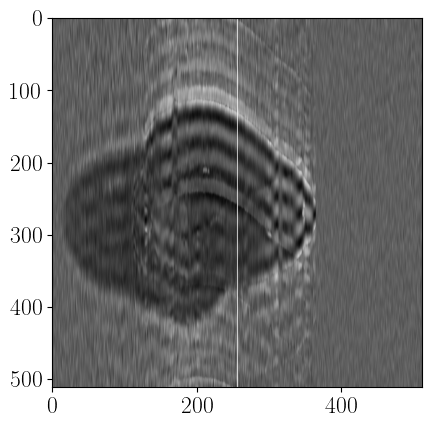

In [132]:
slice_img=np.abs(x_model[0,9,:,:]).clip(-0.1,0.1)
plt.imshow(slice_img,cmap='gray');plt.show()

## Zero fill undersampled k-space for DeepInverse

In [15]:
pe_index = acq_data.get_ISMRMRD_info('kspace_encode_step_1')
slice_index = acq_data.get_ISMRMRD_info('slice')

In [16]:
k_list = acq_data.as_array()
k_array = np.zeros((18, 512, 18, 512), dtype=np.complex64) #(slices, phase encoding, coils, readout
for idx in range(k_list.shape[0]):
    if pe_index[idx] < 512:
        k_array[slice_index[idx], pe_index[idx],:,:] = k_list[idx,:,:]

/tmp/ipykernel_473514/1177315028.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(k_slice),cmap='gray')


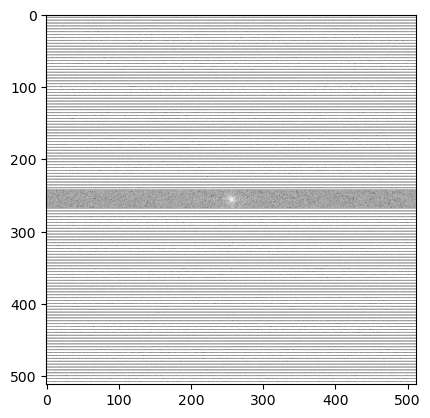

In [17]:
k_slice=abs(np.squeeze(k_array[10,:,0,:]))
plt.imshow(np.log(k_slice),cmap='gray')

In [18]:
mask=k_slice==0
sampling=np.sum(mask)/np.multiply(*k_slice.shape)
print(sampling)

0.712890625


## DeepInverse

In [19]:
csm.shape
coil_map=torch.from_numpy(csm.as_array())
coil_map = coil_map.permute(0, 1, 3, 2) # BNXY
y = torch.from_numpy(k_array).permute(0, 2, 3, 1)
y = dinv.utils.MRIMixin.from_torch_complex(y) # B2NHW
print(y.shape)
print(coil_map.shape)

torch.Size([18, 2, 18, 512, 512])
torch.Size([18, 18, 512, 512])


In [20]:
y_slice=y[[11]]
coil_slice=coil_map[[11]]
mask= (y_slice!=0).float()[[0], [0], [0]].unsqueeze(0)

In [36]:
physics = dinv.physics.MultiCoilMRI(mask=mask, coil_maps=coil_slice)

In [225]:
coil_maps_espirit = physics.estimate_coil_maps(y_slice, calib_size=26)

In [226]:
physics.update(coil_maps=coil_maps_espirit)

In [227]:
x_sense = physics.A_dagger(y_slice)

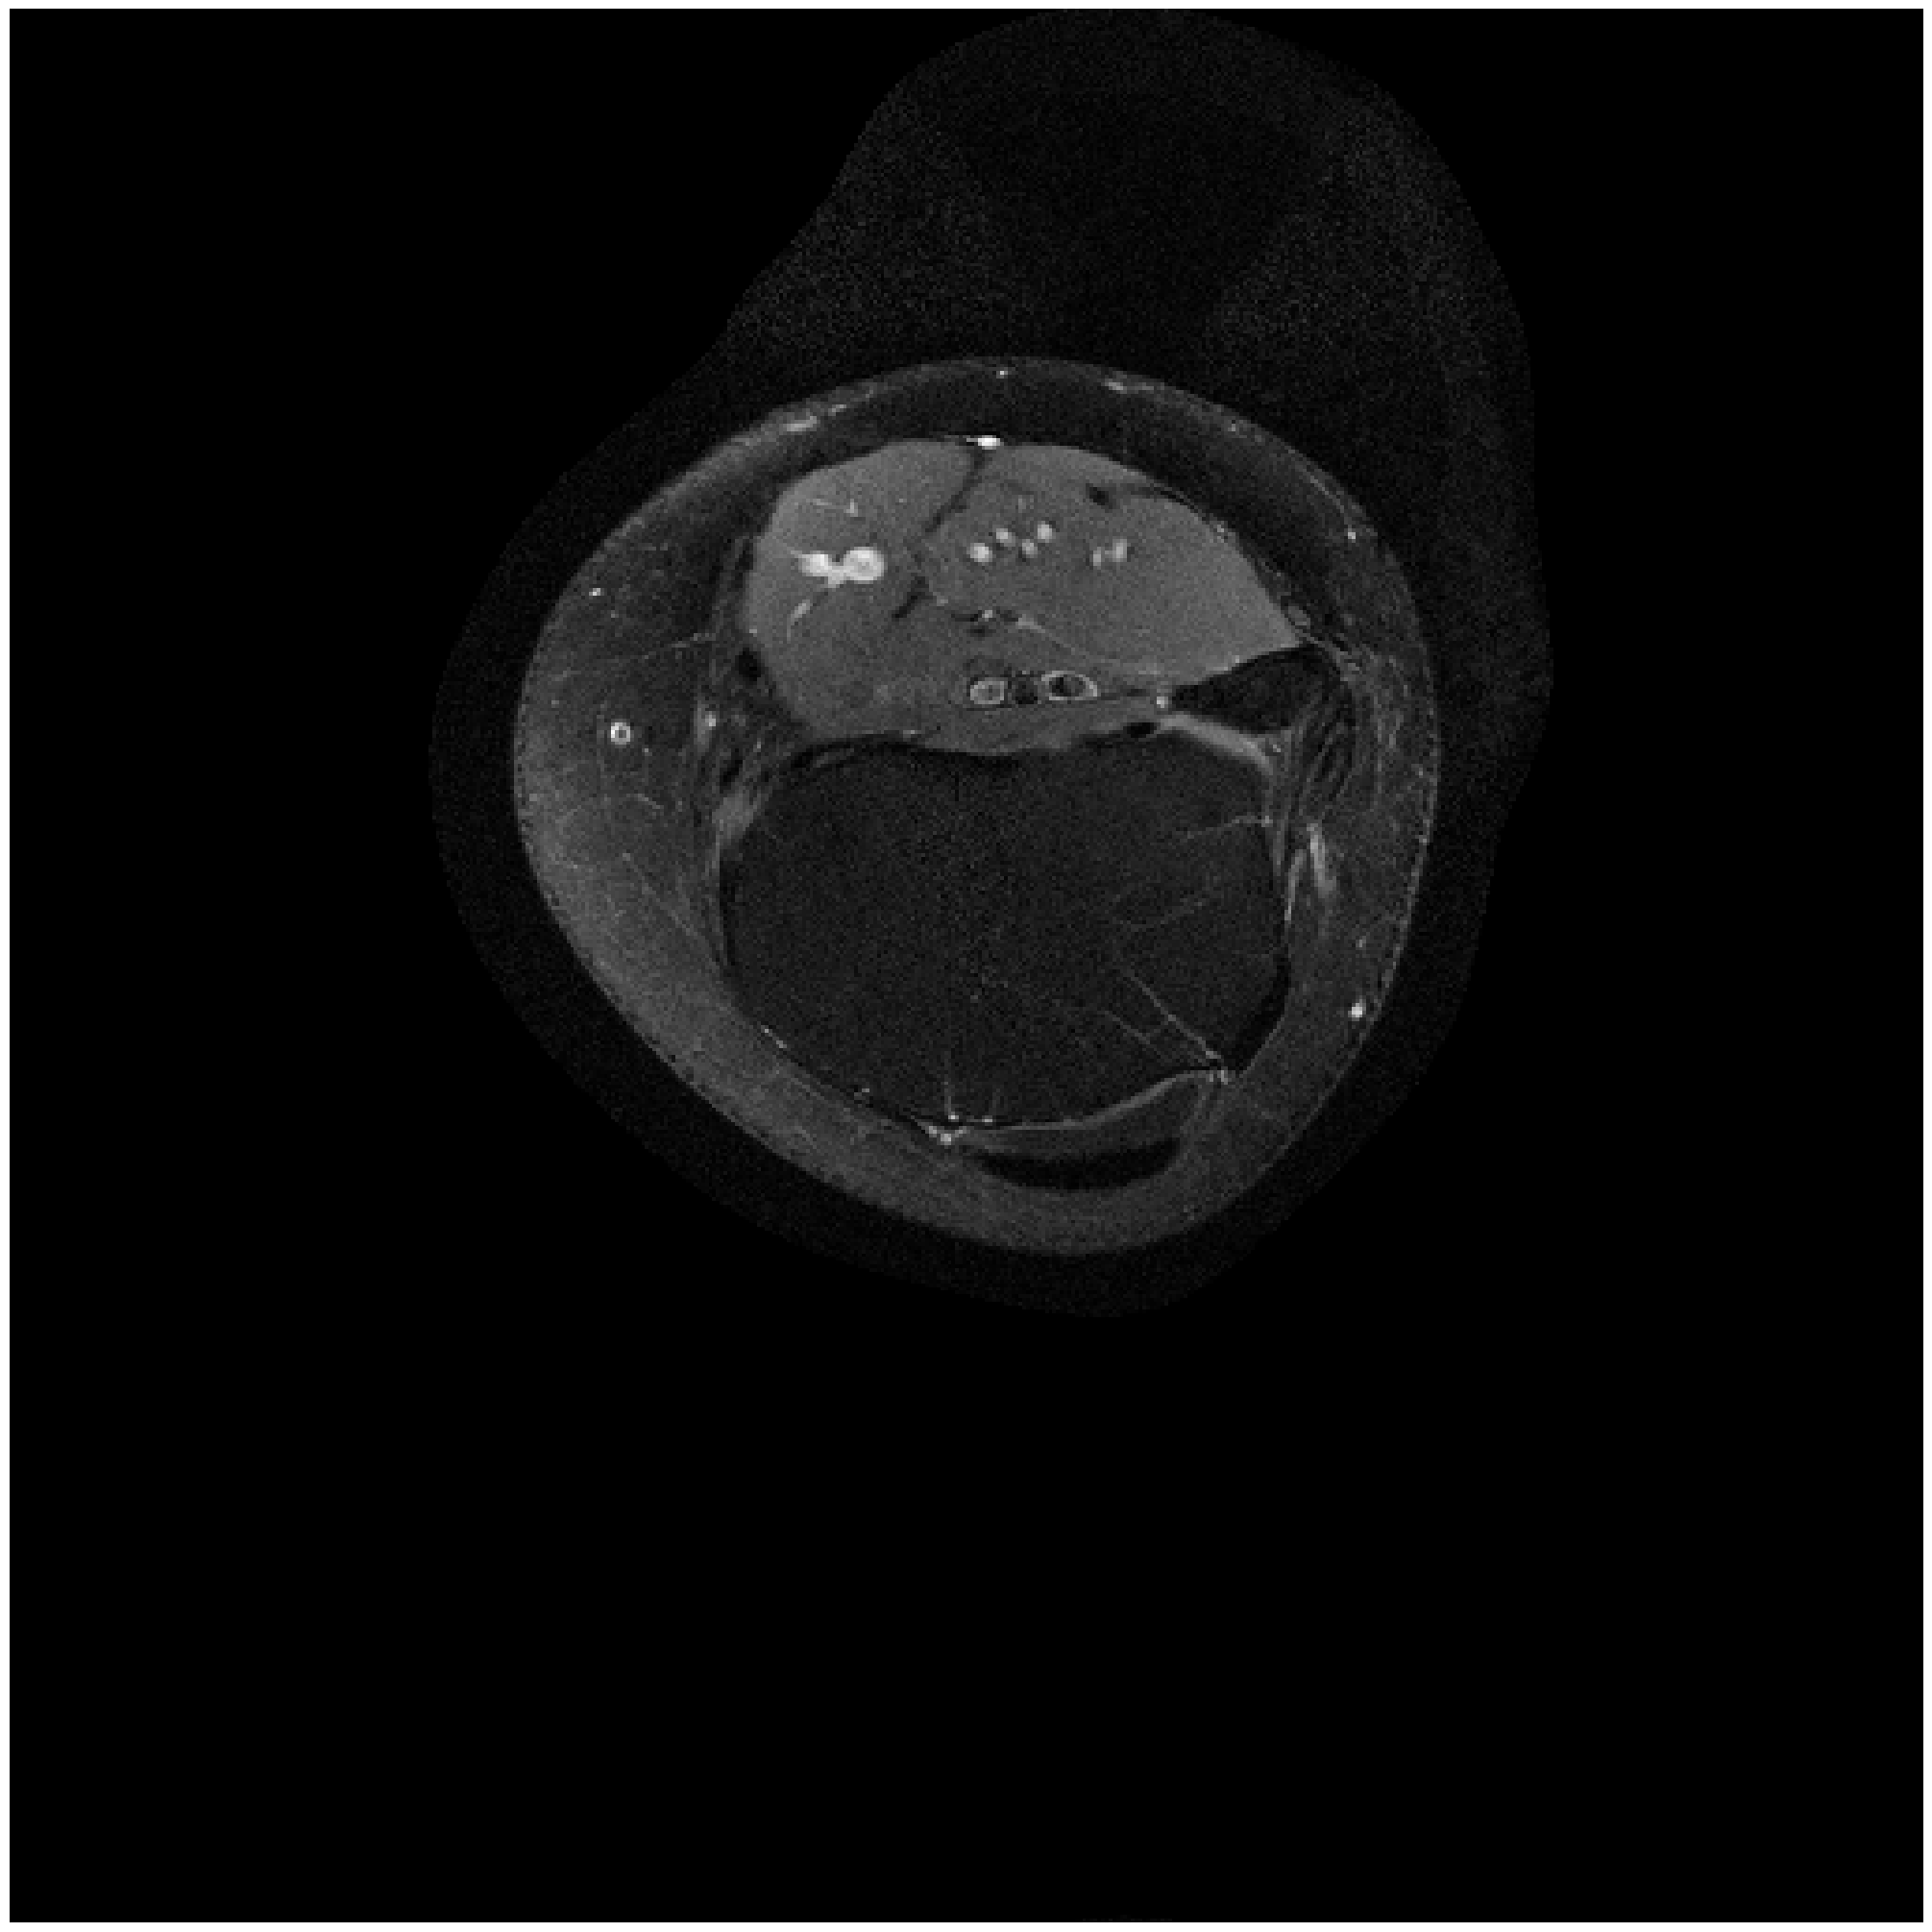

In [228]:
dinv.utils.plot(dinv.utils.complex_abs(x_sense).clip(-200, 200), figsize=(20,20))

## Solve with ADMM

In [30]:
class RGBAdapter(nn.Module):
    def __init__(self, denoiser):
        super().__init__()
        self.denoiser = denoiser

    def forward(self, x, sigma):
        # x is (B, 1, H, W) or (B, 2, H, W)
        # 1. Expand to 3 channels for DnCNN
        x_rgb = x.repeat(1, 3 // x.shape[1], 1, 1) 
        
        # 2. Denoise
        out_rgb = self.denoiser(x_rgb, sigma)
        
        # 3. Average back to original channel count
        return out_rgb.mean(dim=1, keepdim=True)

# Update your prior setup
base_dncnn = dinv.models.DnCNN(depth=20, pretrained="download").to(device)
adapted_denoiser = RGBAdapter(base_dncnn)


In [31]:
# Create a custom prior which inherits from the base Prior class.
class L2Prior(Prior):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.explicit_prior = True

    def fn(self, x, args, **kwargs):
        return (
            0.5 * torch.linalg.vector_norm(x, dim=tuple(range(1, x.dim())), ord=2) ** 2
        )


# Specify the custom prior
prior = dinv.optim.TVPrior()#L2Prior()
#prior=prior = RED(denoiser=dinv.models.DnCNN(depth=20, pretrained="download").to(device))
#prior = RED(denoiser=adapted_denoiser)
# Select the data fidelity term
data_fidelity = L2()

# Logging parameters
verbose = True

# Parameters of the algorithm to solve the inverse problem
early_stop = True  # Stop algorithm when convergence criteria is reached
crit_conv = "cost"  # Convergence is reached when the difference of cost function between consecutive iterates is
# smaller than thres_conv
thres_conv = 1e-5
max_iter = 50  # Maximum number of iterations
sigma_denoiser = 0.05  # noise level parameter of the Gaussian denoiser

# Instantiate the algorithm class to solve the IP problem.
model = ADMM(
    prior=prior,
    g_first=False,
    data_fidelity=data_fidelity,
    sigma_denoiser=sigma_denoiser,
    stepsize=1.0,
    lambda_reg=0.5,
    early_stop=early_stop,
    max_iter=max_iter,
    crit_conv=crit_conv,
    thres_conv=thres_conv,
    verbose=verbose,
)

In [32]:
#y_channels=y_slice.unsqueeze(3).repeat(1,1,1,3,1,1)
#y_channels.shape
#print(y_channels.shape)
#coil_channels=coil_slice.unsqueeze(2).repeat(1,1,3,1,1)
#coil_channels.shape

#physics.update(coil_maps=coil_channels)

In [33]:
# Move slices to batch dimension: (Batch*Slices, Complex, H, W)
y_for_net = y_slice.permute(0, 2, 1, 3, 4).flatten(0, 1)

In [41]:
y_slice=y_slice.unsqueeze(0).unsqueeze(0)
x_model=model(y_slice,physics)

ValueError: cannot fill ImageData of size (np.int32(18), np.int32(512), np.int32(512)) with data of size (1, 1, 1, 2, 18, 512, 512)

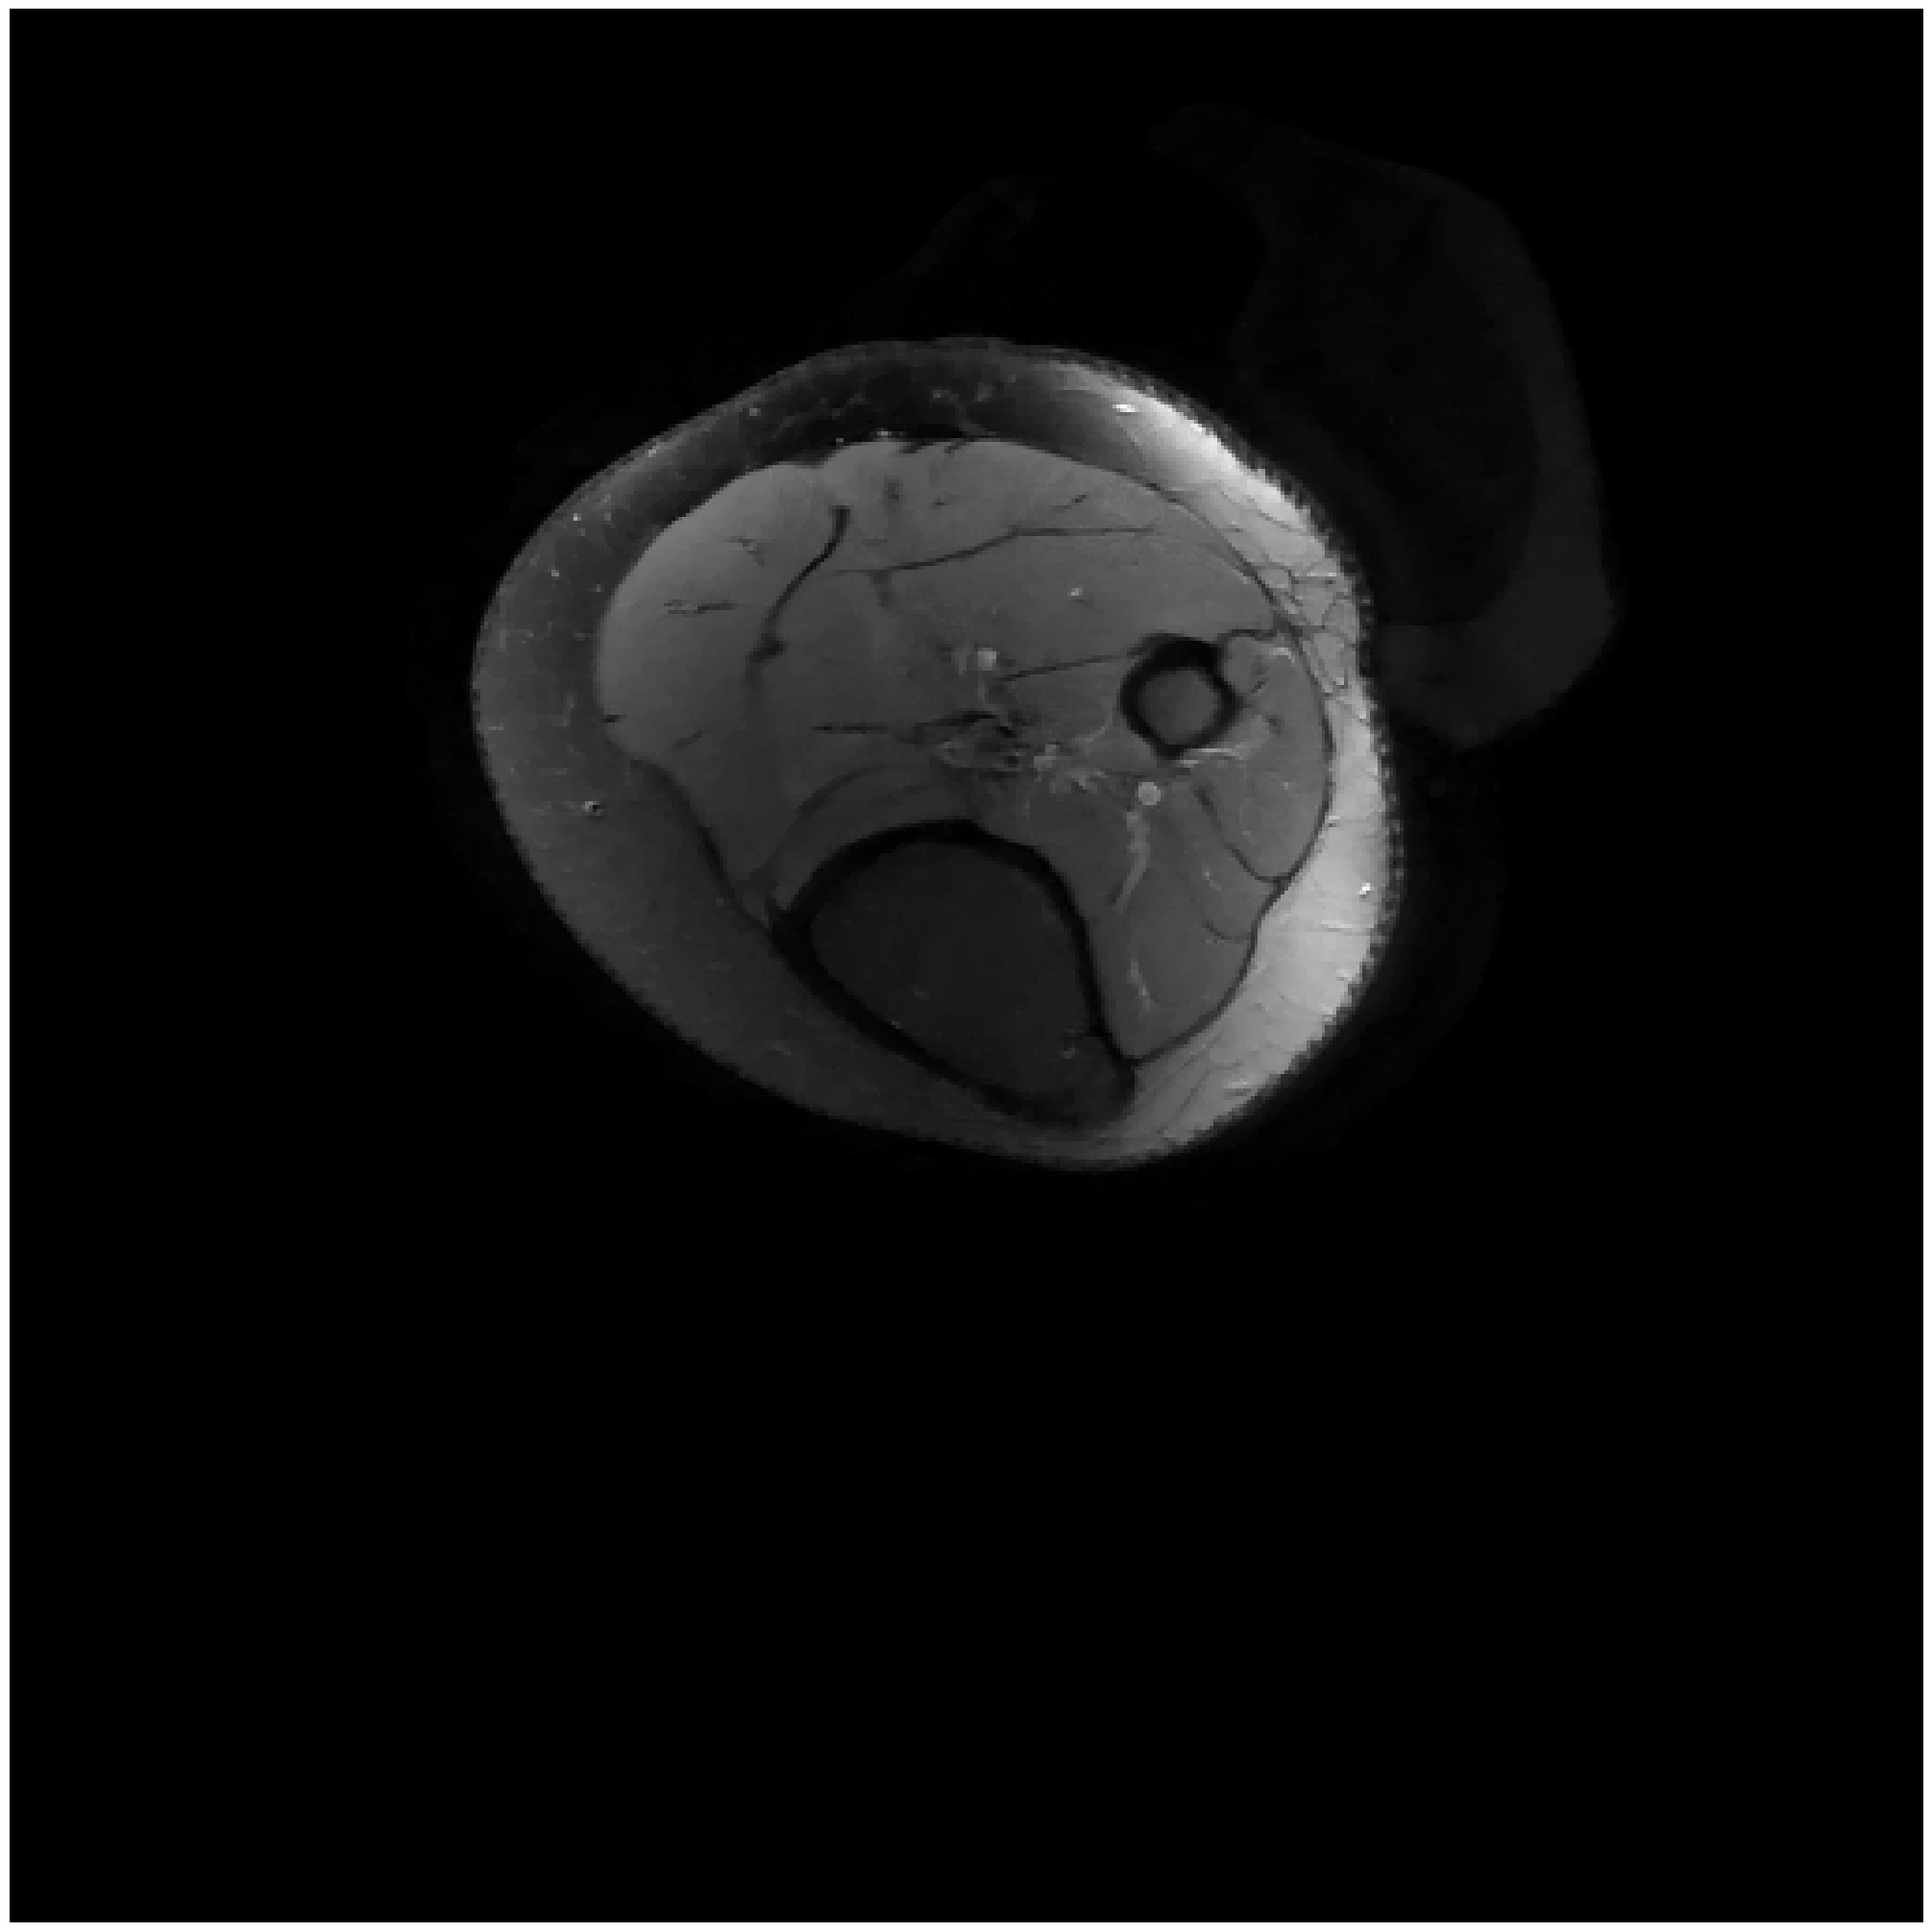

In [208]:
dinv.utils.plot(dinv.utils.complex_abs(x_model).clip(-200, 200), figsize=(20,20))

## Deep denoiser for the proximal step

In [211]:
from deepinv.optim.prior import RED
from deepinv.optim import PGD
from deepinv.training import test
from torchvision import transforms
from deepinv.utils.parameters import get_GSPnP_params

[RED](https://deepinv.github.io/deepinv/auto_examples/plug-and-play/demo_RED_GSPnP_SR.html)

In [214]:
# Parameters of the algorithm to solve the inverse problem
early_stop = True  # Stop algorithm when convergence criteria is reached
crit_conv = "cost"  # Convergence is reached when the difference of cost function between consecutive iterates is
# smaller than thres_conv
thres_conv = 1e-5
backtracking = True
batch_size = 1  # batch size for evaluation is necessarily 1 for early stopping and backtracking to work.
operation = "super-resolution"
noise_level_img = 0.03  # Gaussian Noise standard deviation for the degradation

# load specific parameters for GSPnP
lambda_reg, sigma_denoiser, stepsize, max_iter = get_GSPnP_params(
    operation, noise_level_img
)

# Select the data fidelity term
data_fidelity = L2()


# The GSPnP prior corresponds to a RED prior with an explicit `g`.
# We thus write a class that inherits from RED for this custom prior.
class GSPnP(RED):
    r"""
    Gradient-Step Denoiser prior.
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.explicit_prior = True

    def forward(self, x, *args, **kwargs):
        r"""
        Computes the prior :math:`g(x)`.

        :param torch.Tensor x: Variable :math:`x` at which the prior is computed.
        :return: (torch.Tensor) prior :math:`g(x)`.
        """
        return self.denoiser.potential(x, *args, **kwargs)


method = "GSPnP"
denoiser_name = "gsdrunet"
# Specify the Denoising prior
prior = GSPnP(denoiser=dinv.models.GSDRUNet(pretrained="download").to(device))


# we want to output the intermediate PGD update to finish with a denoising step.
def custom_output(X):
    return X["est"][1]


# instantiate the algorithm class to solve the IP problem.
model = PGD(
    prior=prior,
    g_first=True,
    data_fidelity=data_fidelity,
    sigma_denoiser=sigma_denoiser,
    lambda_reg=lambda_reg,
    stepsize=stepsize,
    early_stop=early_stop,
    max_iter=max_iter,
    crit_conv=crit_conv,
    thres_conv=thres_conv,
    backtracking=backtracking,
    get_output=custom_output,
    verbose=False,
)

# Set the model to evaluation mode. We do not require training here.
model.eval()

Downloading: "https://huggingface.co/deepinv/gradientstep/resolve/main/GSDRUNet_torch.ckpt?download=true" to /home/jovyan/.cache/torch/hub/checkpoints/GSDRUNet_torch.ckpt


100% 64.9M/64.9M [00:01<00:00, 67.4MB/s]


PGD(
  (fixed_point): FixedPoint(
    (iterator): PGDIteration(
      (f_step): fStepPGD()
      (g_step): gStepPGD()
    )
  )
  (psnr): PSNR()
)

In [216]:
y_slice.shape

torch.Size([1, 2, 18, 512, 512])

In [215]:
x_model=model(y_slice,physics)

RuntimeError: Given groups=1, weight of size [64, 4, 3, 3], expected input[1, 3, 512, 512] to have 4 channels, but got 3 channels instead

In [ ]:
dinv.utils.plot(dinv.utils.complex_abs(x_model).clip(-200, 200), figsize=(20,20))


# Self-supervised MRI reconstruction with Artifact2Artifact

We demonstrate the self-supervised Artifact2Artifact loss for solving an
undersampled sequential MRI reconstruction problem without ground truth.

The Artifact2Artifact loss was introduced by :footcite:t:`liu2020rare`.

In our example, we use it to reconstruct **static** images, where the
k-space measurements is a time-sequence, where each time step (phase)
consists of sampled lines such that the whole measurement is a set of
non-overlapping lines.

For a description of how Artifact2Artifact constructs the loss, see
:class:`deepinv.loss.mri.Artifact2ArtifactLoss`.

Note in our implementation, this is a special case of the generic
splitting loss: see :class:`deepinv.loss.SplittingLoss` for more
details. See :class:`deepinv.loss.mri.Phase2PhaseLoss` for the related
Phase2Phase.


In [82]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

import deepinv as dinv
from deepinv.datasets import SimpleFastMRISliceDataset
from deepinv.utils import get_data_home
from deepinv.models.utils import get_weights_url
from deepinv.models import MoDL
from deepinv.physics.generator import (
    GaussianMaskGenerator,
    BernoulliSplittingMaskGenerator,
)

import sirf

torch.manual_seed(0)
device = torch.device('cuda:0')#dinv.utils.get_device()

In [40]:
import h5py

file_path = 'work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL.h5'

with h5py.File(file_path, 'r') as hf:
    print(f"Structure of {file_path}:")
    # This loop visits every item in the file and prints its name
    hf.visit(print)

    a=hf['dataset/data']

Structure of work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL.h5:
dataset
dataset/data
dataset/xml


## Load data




In [5]:
# In this example, we use a mini demo subset of the single-coil `FastMRI dataset <https://fastmri.org/>`_
# as the base image dataset, consisting of knees of size 320x320, and then resized to 128x128 for speed.
#
# .. important::
#
#    By using this dataset, you confirm that you have agreed to and signed the `FastMRI data use agreement <https://fastmri.med.nyu.edu/>`_.
#
# .. seealso::
#
#   Datasets :class:`deepinv.datasets.FastMRISliceDataset` :class:`deepinv.datasets.SimpleFastMRISliceDataset`
#       We provide convenient datasets to easily load both raw and reconstructed FastMRI images.
#       You can download more data on the `FastMRI site <https://fastmri.med.nyu.edu/>`_.
#
#
# We use a train set of size 1 and test set of size 1 in this demo for
# speed to fine-tune the original model. To train the original
# model from scratch, use a larger dataset of size ~150.
#

batch_size = 1
H = 128

transform = transforms.Compose([transforms.Resize(H)])

train_dataset = SimpleFastMRISliceDataset(
    get_data_home(), transform=transform, train=True, download=True, train_percent=0.5
)
test_dataset = SimpleFastMRISliceDataset(
    get_data_home(), transform=transform, train=False, train_percent=0.5
)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

  0%|          | 0/820529 [00:00<?, ?it/s]

## Define physics

We simulate a sequential k-space sampler, that, over the course of 4
phases (i.e. frames), samples 64 lines (i.e 2x total undersampling from
128) with Gaussian weighting (plus a few extra for the ACS signals in
the center of the k-space). We use
:class:`deepinv.physics.SequentialMRI` to do this.

First, we define a static 2x acceleration mask that all measurements use
(of shape [B,C,H,W]):




In [6]:
mask_full = GaussianMaskGenerator((2, H, H), acceleration=2, device=device).step(
    batch_size=batch_size
)["mask"]

Next, we randomly share the sampled lines across 4 time-phases into a
time-varying mask:




In [7]:
# Split only in horizontal direction
masks = [mask_full[..., 0, :]]
splitter = BernoulliSplittingMaskGenerator((2, H), split_ratio=0.5, device=device)

acs = 10

# Split 4 times
for _ in range(2):
    new_masks = []
    for m in masks:
        m1 = splitter.step(batch_size=batch_size, input_mask=m)["mask"]
        m2 = m - m1
        m1[..., H // 2 - acs // 2 : H // 2 + acs // 2] = 1
        m2[..., H // 2 - acs // 2 : H // 2 + acs // 2] = 1
        new_masks.extend([m1, m2])
    masks = new_masks

# Merge masks into time dimension
mask = torch.stack(masks, 2)

# Convert to vertical lines
mask = torch.stack([mask] * H, -2)

/opt/conda/lib/python3.12/site-packages/deepinv/physics/generator/inpainting.py:153: UserWarning: Generating pixelwise mask assumes channel in first dimension. For 2D images (i.e. of shape (H,W)) ensure img_size is at least 3D (i.e. C,H,W). However, for img_size of shape (C,M), this will work as expected.
  warn(


Now define physics using this time-varying mask of shape [B,C,T,H,W]:




In [8]:
physics = dinv.physics.SequentialMRI(mask=mask, device=device)

Let's visualize the sequential measurements using a sample image (run
this notebook yourself to display the video). We also visualize the
frame-by-frame no-learning zero-filled reconstruction.




In [9]:
x = next(iter(train_dataloader)).to(device)
y = physics(x)
dinv.utils.plot_videos(
    [physics.repeat(x, mask), y, mask, physics.A_adjoint(y, keep_time_dim=True)],
    titles=["x", "y", "mask", "x_init"],
    display=True,
)

Also visualize the flattened time-series, recovering the original 2x
undersampling mask (note the actual undersampling factor is much lower
due to ACS lines):




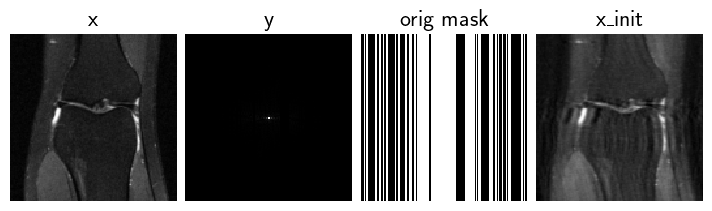

Total acceleration: tensor(1.3617, device='cuda:0')


In [10]:
dinv.utils.plot(
    [x, physics.average(y), physics.average(mask), physics.A_adjoint(y)],
    titles=["x", "y", "orig mask", "x_init"],
)

print("Total acceleration:", (2 * 128 * 128) / mask.sum())

## Define model

As a (static) reconstruction network, we use an unrolled network
(half-quadratic splitting) with a trainable denoising prior based on the
DnCNN architecture which was proposed in MoDL :footcite:t:`aggarwal2018modl`.
See :class:`deepinv.models.MoDL` for details.




In [11]:
model = MoDL().to(device)

## Prep loss

Perform loss on all collected lines by setting ``dynamic_model`` to
False. Then adapt model to perform Artifact2Artifact. We set
``split_size=1`` to mean that each Artifact chunk containes only 1
frame.




In [12]:
loss = dinv.loss.mri.Artifact2ArtifactLoss(
    (2, 4, H, H), split_size=1, dynamic_model=False, device=device
)
model = loss.adapt_model(model)

## Train model

Original model is trained for 100 epochs. We demonstrate loading the
pretrained model then fine-tuning with 1 epoch. Report PSNR and SSIM. To
train from scratch, simply comment out the model loading code and
increase the number of epochs.

To simulate a realistic self-supervised learning scenario, we do not use any supervised metrics for training,
such as PSNR or SSIM, which require clean ground truth images.

.. tip::

      We can use the same self-supervised loss for evaluation, as it does not require clean images,
      to monitor the training process (e.g. for early stopping). This is done automatically when `metrics=None` and `early_stop>0` in the trainer.



In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)

# Load pretrained model
file_name = "demo_artifact2artifact_mri.pth"
url = get_weights_url(model_name="measplit", file_name=file_name)
ckpt = torch.hub.load_state_dict_from_url(
    url, map_location=lambda storage, loc: storage, file_name=file_name
)

model.load_state_dict(ckpt["state_dict"], strict=False)
optimizer.load_state_dict(ckpt["optimizer"])

# Initialize the trainer
trainer = dinv.Trainer(
    model,
    physics=physics,
    epochs=1,
    losses=loss,
    optimizer=optimizer,
    train_dataloader=train_dataloader,
    compute_eval_losses=True,  # use self-supervised loss for evaluation
    early_stop_on_losses=True,  # stop using self-supervised eval loss
    metrics=None,
    eval_dataloader=test_dataloader,
    early_stop=2,  # early stop using the self-supervised loss on the test set
    online_measurements=True,
    device=device,
    save_path=None,
    verbose=True,
    show_progress_bar=False,
)

model = trainer.train()

# Test the model

We now assume that we have access to a small test set of ground-truth images to evaluate the performance of the trained network.
and we compute the PSNR between the denoised images and the clean ground truth images.




In [ ]:
trainer.plot_images = True
trainer.test(test_dataloader, metrics=[dinv.metric.PSNR(), dinv.metric.SSIM()])

:References:

.. footbibliography::

